In [2]:
import sys
sys.path.append("..")

import pandas as pd
import mlflow
from src.data.data_cleaning import load_config, project_path
from src.models.baseline_model import time_based_split
from src.models.train_model import evaluate_forecast, setup_mlflow, log_run
from src.models.xgboost_model import get_feature_columns, prepare_xy, tune_xgboost, train_final_xgboost

config = load_config("config/config.yaml")

In [3]:
df = pd.read_csv(project_path(config["data"]["processed_path"]))
df["date"] = pd.to_datetime(df["date"])
target = config["data"]["target"]

train, test = time_based_split(df, config)

feature_cols = get_feature_columns(df, target)
X_train, y_train = prepare_xy(train, target, feature_cols)
X_test, y_test = prepare_xy(test, target, feature_cols)

print("Jumlah fitur:", len(feature_cols))
print(feature_cols)

Jumlah fitur: 15
['promo', 'is_holiday', 'day_of_week', 'is_weekend', 'month', 'day_of_year', 'week_of_year', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'sales_rolling_mean7', 'sales_rolling_std7', 'sales_rolling_mean30', 'sales_rolling_std30']


In [4]:
study = tune_xgboost(X_train, y_train, config, n_trials=50)
print("Best RMSE (CV):", study.best_value)
print("Best params:", study.best_params)

[I 2026-07-30 15:44:22,286] A new study created in memory with name: no-name-297d928c-9df2-4f75-b0b8-615ae13feb64
Best trial: 0. Best value: 40.6056:   2%|▏         | 1/50 [00:02<02:22,  2.91s/it]

[I 2026-07-30 15:44:25,222] Trial 0 finished with value: 40.60558977017926 and parameters: {'n_estimators': 124, 'max_depth': 5, 'learning_rate': 0.09281042440314465, 'subsample': 0.7603398340400374, 'colsample_bytree': 0.9454599848381774}. Best is trial 0 with value: 40.60558977017926.


Best trial: 1. Best value: 39.8164:   4%|▍         | 2/50 [00:08<03:47,  4.74s/it]

[I 2026-07-30 15:44:31,239] Trial 1 finished with value: 39.816440745123714 and parameters: {'n_estimators': 348, 'max_depth': 7, 'learning_rate': 0.06270477324593166, 'subsample': 0.6101301576541963, 'colsample_bytree': 0.6586588340763827}. Best is trial 1 with value: 39.816440745123714.


Best trial: 1. Best value: 39.8164:   6%|▌         | 3/50 [00:15<04:13,  5.39s/it]

...

[I 2026-07-30 15:46:56,634] Trial 47 finished with value: 38.32815697030803 and parameters: {'n_estimators': 192, 'max_depth': 4, 'learning_rate': 0.03630215477186241, 'subsample': 0.6724541592636745, 'colsample_bytree': 0.7857882163129407}. Best is trial 39 with value: 36.2786619692708.


Best trial: 39. Best value: 36.2787:  98%|█████████▊| 49/50 [02:35<00:02,  2.25s/it]

[I 2026-07-30 15:46:57,995] Trial 48 finished with value: 37.16851344816761 and parameters: {'n_estimators': 217, 'max_depth': 3, 'learning_rate': 0.04487596332315826, 'subsample': 0.625393126304502, 'colsample_bytree': 0.9334817879627596}. Best is trial 39 with value: 36.2786619692708.


Best trial: 39. Best value: 36.2787: 100%|██████████| 50/50 [02:37<00:00,  3.14s/it]

[I 2026-07-30 15:46:59,517] Trial 49 finished with value: 39.66842601744325 and parameters: {'n_estimators': 141, 'max_depth': 3, 'learning_rate': 0.09463517547307475, 'subsample': 0.6189884624372556, 'colsample_bytree': 0.92756361462628}. Best is trial 39 with value: 36.2786619692708.
Best RMSE (CV): 36.2786619692708
Best params: {'n_estimators': 229, 'max_depth': 3, 'learning_rate': 0.05298380208097117, 'subsample': 0.6636622273749523, 'colsample_bytree': 0.7535158814215889}


In [ ]:
import optuna.visualization as vis
vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()


In [6]:
final_model = train_final_xgboost(X_train, y_train, study.best_params, config)
xgb_preds = final_model.predict(X_test)
xgb_metrics = evaluate_forecast(y_test.values, xgb_preds)
print("XGBoost (tuned) metrics on test set:", xgb_metrics)

XGBoost (tuned) metrics on test set: {'mae': 38.87244350857205, 'rmse': np.float64(44.18435041445864), 'mape': np.float64(9.499732521405075)}


In [7]:
setup_mlflow(config)
log_run("xgboost_tuned", study.best_params, xgb_metrics, config)

In [8]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False)
importance_df

,feature,importance
13,sales_rolling_mean30,0.282501
11,sales_rolling_mean7,0.221502
8,sales_lag_7,0.108517
0,promo,0.100059
3,is_weekend,0.082570
9,sales_lag_14,0.068696
2,day_of_week,0.039017
1,is_holiday,0.022630
7,sales_lag_1,0.015873
5,day_of_year,0.012169


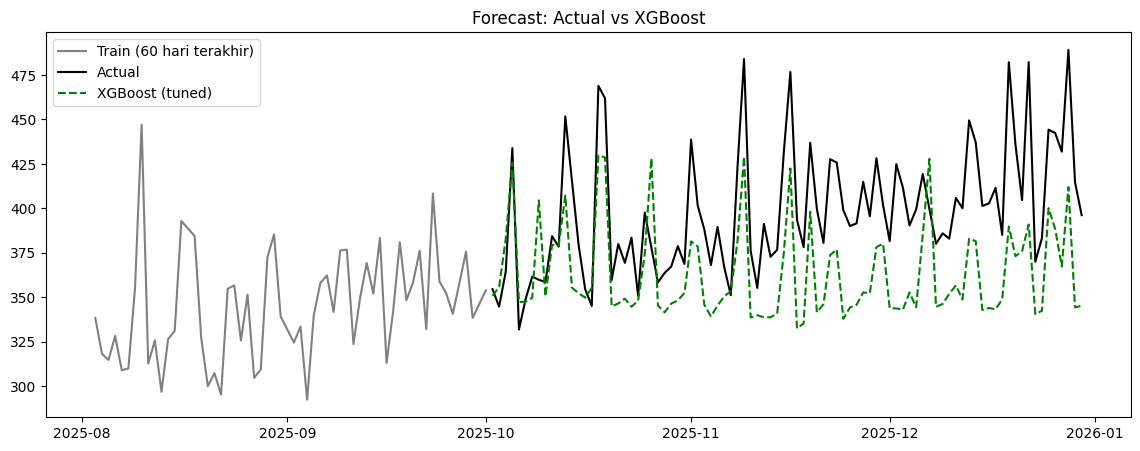

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train["date"].iloc[-60:], train[target].iloc[-60:], label="Train (60 hari terakhir)", color="gray")
ax.plot(test["date"], y_test.values, label="Actual", color="black")
ax.plot(test["date"], xgb_preds, label="XGBoost (tuned)", linestyle="--", color="green")
ax.legend()
ax.set_title("Forecast: Actual vs XGBoost")
plt.show()